# NB_02 — Run Agents

This notebook executes the full evaluation matrix: every question in the dataset is answered by each of the six agent architectures. Each run is fully asynchronous — a `ThreadPoolExecutor` dispatches work where each thread owns its own asyncio event loop, bounded by `concurrency.max_workers` to avoid exhausting the API rate limit. Results are written to `data/evaluation/results/` for downstream evaluation in NB_03.

## Section overview

1. **Configuration and dataset checks** — load questions, verify Qdrant, inspect difficulty and company distribution
2. **Run agents** — dispatch all `architectures × questions` combinations and stream results to disk

## Experiment matrix

| Axis | Values |
|---|---|
| Architectures | 6 (deterministic, planner_executor, router_specialist, blackboard, hierarchical, react) |
| Questions | 90 (balanced across 3 companies × 3 product categories × difficulty levels) |
| Total runs | 540 |

## Prerequisites

- NB_01 completed (Qdrant collection populated)
- Phoenix running: `docker compose up -d phoenix`
- OpenAI API key in `.env`

Run cells from top to bottom.

In [9]:
import sys
from pathlib import Path

# Ensure project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Step 1: Configuration and dataset checks

The dataset contains Polish insurance questions covering three companies (PZU, Warta, Hestia) across three product categories (auto, dom/property, travel) at two difficulty levels:

- **Proste** — factual lookups (coverage limits, named exclusions, procedure steps)
- **Złożone** — reasoning across multiple clauses (eligibility determination, comparative coverage, conditional entitlements)

In [10]:
import logging
import warnings

warnings.filterwarnings("ignore")
for logger_name in ("httpx", "httpcore", "openai", "qdrant_client"):
    logging.getLogger(logger_name).setLevel(logging.WARNING)

import pandas as pd
import structlog
from qdrant_client import QdrantClient

from sources.config import config as app_config
from sources.observer import init_tracing

structlog.configure(
    wrapper_class=structlog.make_filtering_bound_logger(logging.INFO),
)
logger = structlog.get_logger(__name__)

MAX_WORKERS = app_config.concurrency.max_workers
QUESTION_FILES = sorted(app_config.paths.questions_dir.glob("*.csv"))
REVIEW_COLS = [
    "Produkt",
    "Firma",
    "Pytanie",
    "Stopień trudności pytania",
]

init_tracing()

if not QUESTION_FILES:
    raise FileNotFoundError(
        f"No CSV question files found in {app_config.paths.questions_dir}"
    )

QUESTIONS_PATH = QUESTION_FILES[0]

if not QUESTIONS_PATH.exists():
    raise FileNotFoundError(f"Questions file not found: {QUESTIONS_PATH}")

questions_df = pd.read_csv(QUESTIONS_PATH, sep=";")
questions_df = questions_df.rename(
    columns={col: col.strip() for col in questions_df.columns}
)

missing_cols = [col for col in REVIEW_COLS if col not in questions_df.columns]
if missing_cols:
    raise ValueError(f"Questions file is missing required columns: {missing_cols}")

questions = questions_df["Pytanie"].dropna().astype(str).str.strip()
questions = [question for question in questions if question]

qd = QdrantClient(host=app_config.qdrant.host, port=app_config.qdrant.port)
collection_info = qd.get_collection(app_config.qdrant.collection_name)
point_count = int(collection_info.points_count or 0)
if point_count == 0:
    raise ValueError(
        "Qdrant collection is empty. Run NB_01 first to build the flat vector index."
    )

logger.info(
    "run_config",
    collection=app_config.qdrant.collection_name,
    qdrant_host=app_config.qdrant.host,
    qdrant_port=app_config.qdrant.port,
    points=point_count,
    questions_path=str(QUESTIONS_PATH),
    questions=len(questions),
    worker_threads=MAX_WORKERS,
    llm_models=app_config.llm.role_models(),
)

logger.info(
    "dataset_sample",
    rows=questions_df[REVIEW_COLS].head(5).fillna("").to_dict(orient="records"),
)

2026-05-16 18:09:06 [info     ] tracing_already_initialized   
2026-05-16 18:09:06 [info     ] run_config                     collection=insurance_documents llm_models={'default': 'gpt-5', 'parser': 'gpt-5', 'router': 'gpt-5', 'planner': 'gpt-5', 'controller': 'gpt-5', 'rewrite': 'gpt-5', 'decomposer': 'gpt-5', 'synthesis': 'gpt-5', 'evaluation': 'gpt-5'} points=5107 qdrant_host=localhost qdrant_port=6333 questions=90 questions_path=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/evaluation/questions/questions_20251130.csv worker_threads=32
2026-05-16 18:09:06 [info     ] dataset_sample                 rows=[{'Produkt': 'KL', 'Firma': 'HESTIA', 'Pytanie': 'Ile wariantów ubezpieczenia oferuje ERGO Podróż?', 'Stopień trudności pytania': 'Proste'}, {'Produkt': 'KL', 'Firma': 'HESTIA', 'Pytanie': 'Czy w ERGO Podróże może zostać zawarta umowa grupowa dla 5 osób?', 'Stopień trudności pytania': 'Proste'}, {'Produkt': 'KL', 'Firma': 'HESTIA', 'Pytanie': 'Czy i do jakiej kwoty w ub

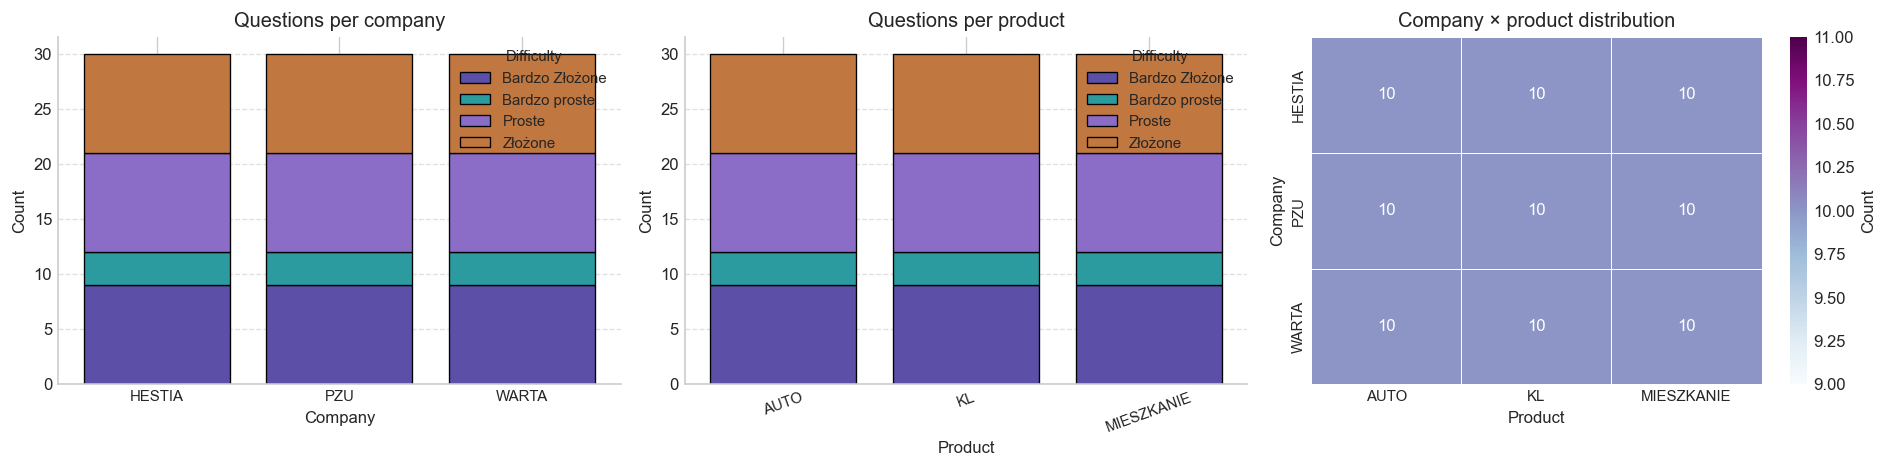


Total questions: 90
Loaded for evaluation: 90


In [14]:
import matplotlib.pyplot as plt
import matplotlib.style as mstyle
import pandas as pd
import seaborn as sns

mstyle.use("seaborn-v0_8-whitegrid")

ARCH_COLORS = {
    "deterministic":     "#5B4FA8",
    "planner_executor":  "#2B9BA0",
    "router_specialist": "#8B6DC8",
    "blackboard":        "#C07840",
    "hierarchical":      "#3A7DB5",
    "react":             "#A84848",
}
HEATMAP_CMAP = "BuPu"

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

# Derive difficulty levels and assign colors dynamically
_diff_col = "Stopień trudności pytania"
_palette = ["#5B4FA8", "#2B9BA0", "#8B6DC8", "#C07840", "#3A7DB5", "#A84848"]
_diff_levels = sorted(questions_df[_diff_col].dropna().unique()) if _diff_col in questions_df.columns else []
_diff_colors = {lvl: _palette[i % len(_palette)] for i, lvl in enumerate(_diff_levels)}

# Panel 1: stacked bar — questions per company split by difficulty
if "Firma" in questions_df.columns and _diff_levels:
    cross_comp = pd.crosstab(questions_df["Firma"], questions_df[_diff_col])[_diff_levels]
    bottom = [0] * len(cross_comp)
    for col in cross_comp.columns:
        axes[0].bar(
            cross_comp.index,
            cross_comp[col],
            bottom=bottom,
            label=col,
            color=_diff_colors[col],
            edgecolor="black",
            linewidth=0.8,
        )
        bottom = [b + v for b, v in zip(bottom, cross_comp[col])]
    axes[0].set_title("Questions per company")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("Company")
    axes[0].legend(title="Difficulty", fontsize=9, title_fontsize=9)
    axes[0].tick_params(axis="x", labelsize=9)
    axes[0].grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
    axes[0].set_axisbelow(True)
    sns.despine(ax=axes[0])

# Panel 2: stacked bar — questions per product split by difficulty
if "Produkt" in questions_df.columns and _diff_levels:
    cross_prod = pd.crosstab(questions_df["Produkt"], questions_df[_diff_col])[_diff_levels]
    bottom = [0] * len(cross_prod)
    for col in cross_prod.columns:
        axes[1].bar(
            cross_prod.index,
            cross_prod[col],
            bottom=bottom,
            label=col,
            color=_diff_colors[col],
            edgecolor="black",
            linewidth=0.8,
        )
        bottom = [b + v for b, v in zip(bottom, cross_prod[col])]
    axes[1].set_title("Questions per product")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("Product")
    axes[1].legend(title="Difficulty", fontsize=9, title_fontsize=9)
    axes[1].tick_params(axis="x", rotation=20, labelsize=9)
    axes[1].grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
    axes[1].set_axisbelow(True)
    sns.despine(ax=axes[1])

# Panel 3: heatmap — company × product question counts
if "Firma" in questions_df.columns and "Produkt" in questions_df.columns:
    heat = pd.crosstab(questions_df["Firma"], questions_df["Produkt"])
    sns.heatmap(
        heat,
        annot=True,
        fmt="d",
        cmap=HEATMAP_CMAP,
        ax=axes[2],
        linewidths=0.5,
        cbar_kws={"label": "Count"},
        annot_kws={"fontsize": 10},
    )
    axes[2].set_title("Company × product distribution")
    axes[2].set_xlabel("Product")
    axes[2].set_ylabel("Company")
    axes[2].tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal questions: {len(questions_df)}")
print(f"Loaded for evaluation: {len(questions)}")


## Step 2: Run agents

Dispatches all `architectures × questions` combinations through a `ThreadPoolExecutor`, with each thread running its own asyncio event loop. Results are streamed to `data/evaluation/results/` as a JSONL file; if a run artifact already exists for the current question set it is loaded from disk and the experiment is skipped.

In [13]:
import json

from sources.agents.factory import ALL_PATTERNS, build_graph
from sources.config.graph import GraphConfig
from sources.runner import METRIC_COLS, Runner

PATTERNS = list(ALL_PATTERNS)
graph_defaults = GraphConfig()

# Skip-if-exists: if results from a previous run are already on disk,
# load them and show a summary without re-running the 540 experiments.
_existing_results = sorted(
    app_config.paths.results_dir.glob("runner_results_*.jsonl"), reverse=True
)
_RESULTS_EXIST = bool(_existing_results)

if _RESULTS_EXIST:
    _rpath = _existing_results[0]
    _run_id_loaded = _rpath.stem.replace("runner_results_", "")
    logger.info(
        "results_already_exist_skipping_run",
        path=str(_rpath),
        run_id=_run_id_loaded,
    )
    with _rpath.open(encoding="utf-8") as _f:
        _raw = [json.loads(line) for line in _f if line.strip()]
    df = pd.DataFrame(_raw)
    logger.info("loaded_existing_results", rows=len(df), run_id=_run_id_loaded)

    # Display per-architecture summary of key operational metrics
    _summary_metrics = [
        col for col in [
            "latency_ms", "completion_flag", "error_flag",
            "tool_count", "citation_count", "estimated_total_cost_usd",
        ] if col in df.columns
    ]
    if _summary_metrics:
        _pattern_summary = (
            df.groupby("pattern_name", as_index=False)[_summary_metrics]
            .mean()
            .round(3)
        )
        logger.info(
            "pattern_summary",
            rows=_pattern_summary.fillna("").to_dict(orient="records"),
        )
else:
    # Preflight: compile every architecture before running the full experiment.
    compile_errors: dict[str, str] = {}
    for pattern_name in PATTERNS:
        try:
            build_graph(GraphConfig(pattern_name=pattern_name))
        except Exception as exc:
            compile_errors[pattern_name] = str(exc)

    if compile_errors:
        raise RuntimeError(f"Graph preflight failed: {compile_errors}")

    logger.info(
        "experiment_setup",
        architectures=PATTERNS,
        total=len(PATTERNS),
        worker_threads=MAX_WORKERS,
        questions_path=str(QUESTIONS_PATH),
        top_k=graph_defaults.top_k,
        evidence_top_k=graph_defaults.evidence_top_k,
        reranker_enabled=graph_defaults.reranker_enabled,
        max_react_iterations=graph_defaults.max_react_iterations,
        max_blackboard_iterations=graph_defaults.max_blackboard_iterations,
    )

    runner = Runner(
        questions_path=QUESTIONS_PATH,
        patterns=PATTERNS,
        max_workers=MAX_WORKERS,
    )

    df = await runner.run()

    expected_runs = len(questions) * len(PATTERNS)
    if len(df) != expected_runs:
        raise AssertionError(
            f"Run count mismatch. Expected {expected_runs}, collected {len(df)}."
        )

    _summary_metrics = [
        col for col in [
            "latency_ms", "completion_flag", "error_flag",
            "tool_count", "citation_count", "estimated_total_cost_usd",
        ] if col in df.columns
    ]
    if _summary_metrics:
        _pattern_summary = (
            df.groupby("pattern_name", as_index=False)[_summary_metrics]
            .mean()
            .round(3)
        )
        logger.info(
            "pattern_summary",
            rows=_pattern_summary.fillna("").to_dict(orient="records"),
        )

    _sample_cols = [
        col for col in ["question", "pattern_name", *METRIC_COLS] if col in df.columns
    ]
    logger.info(
        "results_sample",
        rows=df[_sample_cols].head(5).fillna("").to_dict(orient="records"),
    )
    logger.info(
        "experiment_complete",
        run_id=runner.last_run_id,
        collected=len(df),
        results_dir=str(app_config.paths.results_dir),
        artifacts={name: str(path) for name, path in runner.last_artifacts.items()},
    )

2026-05-16 18:11:12 [info     ] results_already_exist_skipping_run path=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/evaluation/results/runner_results_20260313_200511.jsonl run_id=20260313_200511
2026-05-16 18:11:13 [info     ] loaded_existing_results        rows=540 run_id=20260313_200511
2026-05-16 18:11:13 [info     ] pattern_summary                rows=[{'pattern_name': 'blackboard', 'latency_ms': 91429.353, 'completion_flag': 1.0, 'error_flag': 0.0, 'tool_count': 10.0, 'citation_count': 3.744, 'estimated_total_cost_usd': 0.0}, {'pattern_name': 'deterministic', 'latency_ms': 93020.243, 'completion_flag': 1.0, 'error_flag': 0.0, 'tool_count': 10.0, 'citation_count': 3.722, 'estimated_total_cost_usd': 0.0}, {'pattern_name': 'hierarchical', 'latency_ms': 147095.807, 'completion_flag': 0.989, 'error_flag': 0.011, 'tool_count': 1066.033, 'citation_count': 3.744, 'estimated_total_cost_usd': 0.071}, {'pattern_name': 'planner_executor', 'latency_ms': 84254.604, 'completion_